Descargando datos desde los servidores de VitalDB...


C:\Users\aparr\AppData\Local\Temp\ipykernel_7020\3809024055.py:8: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  caseids = vitaldb.find_cases(track_names)


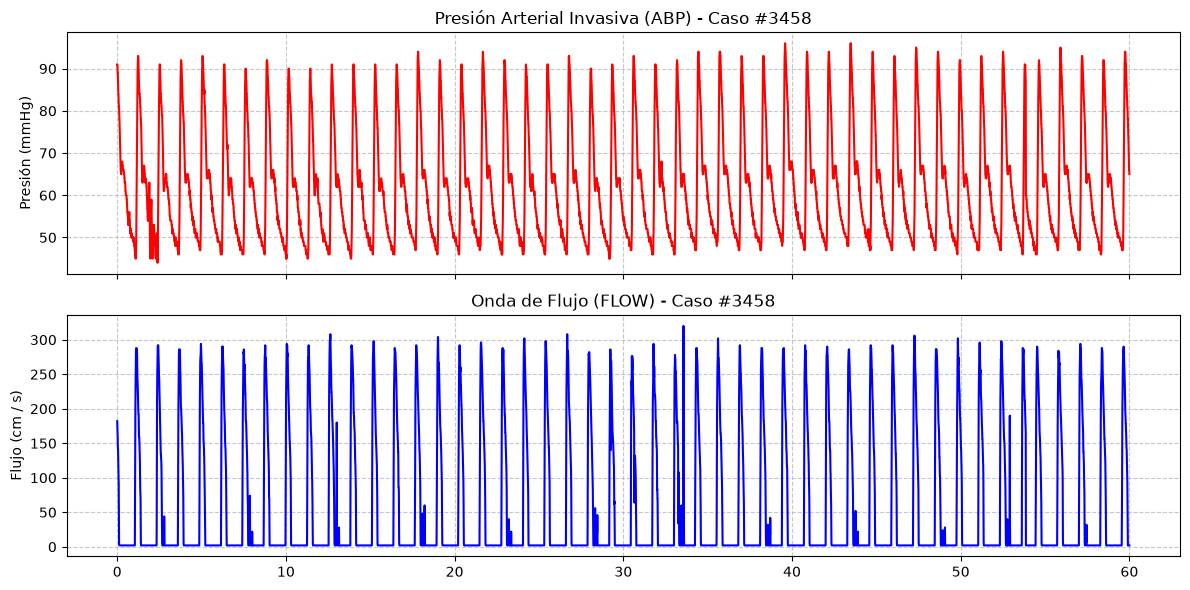

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import vitaldb

track_names = ['CardioQ/ABP', 'CardioQ/FLOW']
print("Descargando datos desde los servidores de VitalDB...")
# Esto te da los caseid que tienen TODAS esas señales
caseids = vitaldb.find_cases(track_names)
FS = 180  # Hz
idx_chosen_patient = 0
CASE_ID = caseids[idx_chosen_patient]
vals = vitaldb.load_case(CASE_ID, track_names, 1 / FS)

art_signal = vals[:, 0]
ppg_signal = vals[:, 1]

valid_idx = ~np.isnan(art_signal) & ~np.isnan(ppg_signal)
art_signal = art_signal[valid_idx]
ppg_signal = ppg_signal[valid_idx]

WINDOW_SECONDS = 60
start_idx = 90000 + 90 * FS
end_idx = start_idx + WINDOW_SECONDS * FS

abp_window = art_signal[start_idx:end_idx]
qflow_window = ppg_signal[start_idx:end_idx]
time = np.linspace(0, WINDOW_SECONDS, len(abp_window))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time, abp_window, color='red', linewidth=1.5)
ax1.set_title(f'Presión Arterial Invasiva (ABP) - Caso #{CASE_ID}')
ax1.set_ylabel('Presión (mmHg)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(time, qflow_window, color='blue', linewidth=1.5)
ax2.set_title(f'Onda de Flujo (FLOW) - Caso #{CASE_ID}')
ax2.set_ylabel('Flujo (cm / s)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

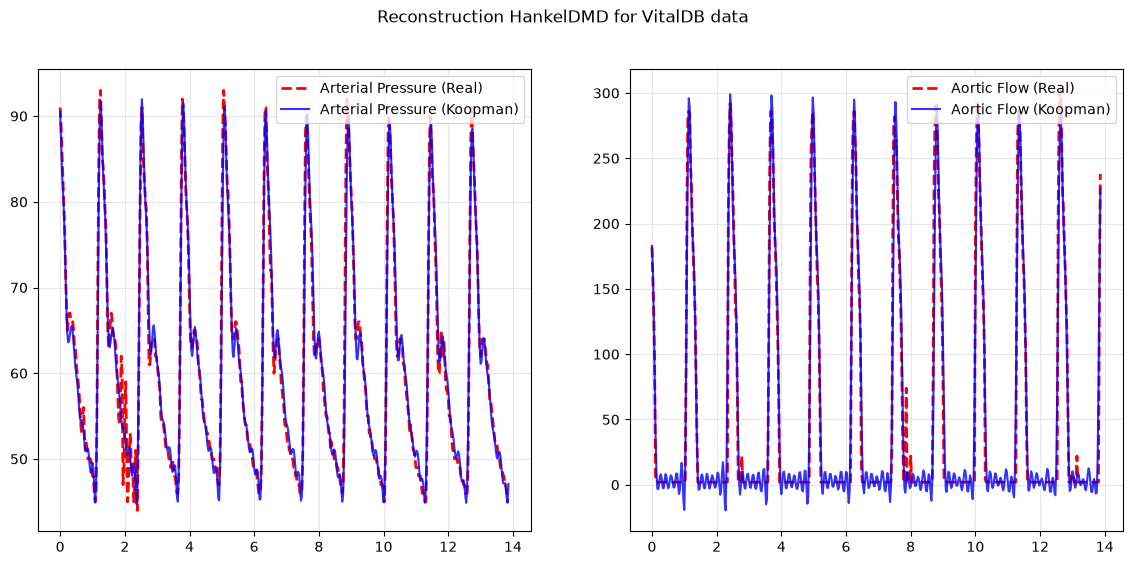

In [67]:
x1 = abp_window[:2500][::5]
x2 = qflow_window[:2500][::5]
t = time[:2500][::5]

x = np.stack([x1, x2])

from pydmd import HankelDMD

dmd = HankelDMD(svd_rank=16, d=90)
dmd.fit(x)

rec = dmd.reconstructed_data.real

# 5. Visualización
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(t, x[0], 'r--', label='Arterial Pressure (Real)', linewidth=2)
plt.plot(t, rec[0], 'b-', label='Arterial Pressure (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(t, x[1], 'r--', label='Aortic Flow (Real)', linewidth=2)
plt.plot(t, rec[1], 'b-', label='Aortic Flow (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.suptitle('Reconstruction HankelDMD for VitalDB data')
plt.show()

C:\Users\aparr\AppData\Local\Temp\ipykernel_7020\3558217357.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


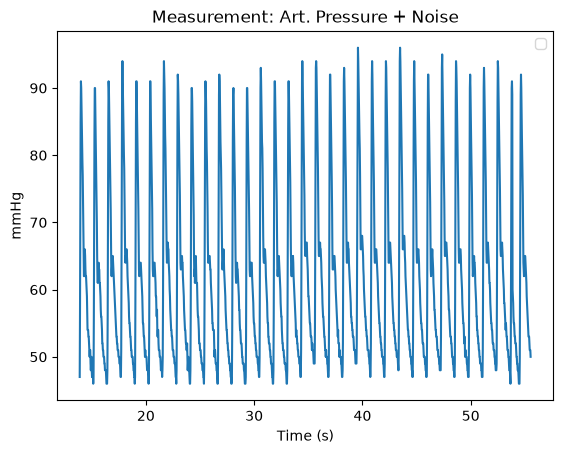

In [68]:
# MEDICION RUIDOSA
idx_fin = 10000
y = abp_window[2500:idx_fin][::5]
x2_real = qflow_window[2500:idx_fin][::5]
t_test = time[2500:idx_fin][::5]
Nt = len(t_test)

plt.plot(t_test, y)
plt.xlabel("Time (s)")
plt.ylabel("mmHg")
plt.title("Measurement: Art. Pressure + Noise")
plt.legend()
plt.show()

# EXTRAER INFORMACIÓN DE KOOPMAN
Lambda = np.diag(dmd.eigs)   # Matriz de transición diagonal (r x r)
Phi = dmd.modes              # Proyección a variables físicas (2 x r)
z0 = dmd.amplitudes           # Estado inicial modal (r,)

# Matrices de observación para Presas (A) y Depredadores (B)
C_A = Phi[0:1, :]  # Fila 0: Presas A
C_B = Phi[1:2, :]  # Fila 1: Depredadores B

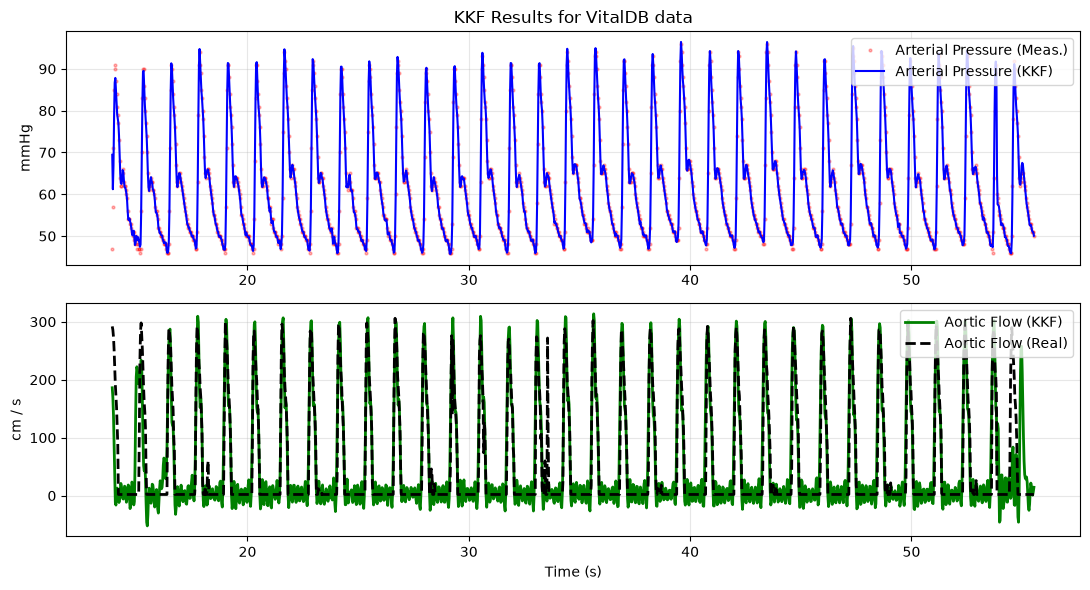

In [69]:
# Inicializar Filtro de Kalman en el espacio modal
r_rank = len(dmd.eigs)
z_hat = z0.astype(complex)

x1_est = np.zeros(Nt)
x2_est = np.zeros(Nt)

# Inicializar Matrices de Covarianzas
P = np.eye(r_rank, dtype=complex) * 1.0
Q = np.eye(r_rank, dtype=complex) * 1.0
sigma_noise = 0.1
R = np.array([[sigma_noise**2]], dtype=complex)

# Filtro de Kalman Online
for k in range(Nt):
    # Paso 1: Predicción (Modos del sistema Koopman)
    if k > 0:
        z_pred = Lambda @ z_hat
        P_pred = Lambda @ P @ Lambda.conj().T + Q
    else:
        z_pred = z_hat
        P_pred = P

    # Paso 2: Lectura del sensor y cálculo de Innovación
    y_k = y[k]
    innovation = y_k - np.real((C_A @ z_pred)[0])

    # Paso 3: Ganancia de Kalman y Corrección de Estado
    S_k = C_A @ P_pred @ C_A.conj().T + R
    K = P_pred @ C_A.conj().T @ np.linalg.inv(S_k)

    z_hat = z_pred + K.flatten() * innovation # Corrección del estado modal
    P = (np.eye(r_rank) - K @ C_A) @ P_pred

    # Paso 4: Inferencia / Reconstrucción de variables usando los modos corregidos
    x1_est[k] = np.real((C_A @ z_hat)[0])
    x2_est[k] = np.real((C_B @ z_hat)[0])

# 5. Visualización de Resultados
plt.figure(figsize=(11, 6))

plt.subplot(2, 1, 1)
plt.plot(t_test, y, 'r.', label='Arterial Pressure (Meas.)', alpha=0.3, markersize=4)
plt.plot(t_test, x1_est, 'b-', label='Arterial Pressure (KKF)', linewidth=1.5)
plt.ylabel('mmHg')
plt.legend(loc='upper right')
plt.title('KKF Results for VitalDB data')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_test, x2_est, 'g-', label='Aortic Flow (KKF)', linewidth=2)
plt.plot(t_test, x2_real, 'k--', label='Aortic Flow (Real)', linewidth=2)
plt.ylabel('cm / s')
plt.xlabel('Time (s)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
rmse_x1 = np.sqrt(np.mean((y - x1_est)**2))
rmse_x2 = np.sqrt(np.mean((x2_real - x2_est)**2))
print(f"RMSE X1: {rmse_x1}")
print(f"RMSE X2: {rmse_x2}")
print()
print(f"RMSE RELATIVO X1: {100 * rmse_x1 / np.ptp(y)} %")
print(f"RMSE RELATIVO X2: {100 * rmse_x2 / np.ptp(x2_real)} %")
print()

Er_x1 = np.median(abs(y - x1_est) / np.ptp(y))
Er_x2 = np.median(abs(x2_real - x2_est) / np.ptp(x2_real))
print(f"ERROR MEDIANO RELATIVO X1: {100 * Er_x1} %")
print(f"ERROR MEDIANO RELATIVO X2: {100 * Er_x2} %")

RMSE X1: 0.7603167531070166
RMSE X2: 37.96170722149738

RMSE RELATIVO X1: 1.5206335062140333 %
RMSE RELATIVO X2: 12.487403691282031 %

ERROR MEDIANO RELATIVO X1: 0.3535659770067028 %
ERROR MEDIANO RELATIVO X2: 4.131727130782598 %
